In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install node2vec tensorflow tensorflow-hub tensorflow_text

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 30.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requi

In [ ]:
import pandas as pd
from tqdm import tqdm
import json
import os
import random
import math
import pickle
import numpy as np
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, confusion_matrix
from collections import deque

import networkx as nx
import warnings
import keras
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import activations, initializers, constraints, regularizers
from tensorflow.keras.layers import Input, Layer, Lambda, Dropout, Reshape, Dense, Embedding,LeakyReLU, Maximum
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras import layers, optimizers, losses, metrics, Model
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.test.utils import datapath
from gensim.models import KeyedVectors
from gensim.models import Word2Vec

%matplotlib inline

In [ ]:
dataFrame = pd.read_csv("/content/drive/MyDrive/Journal/citation_sentiment_corpus.txt", sep = "	", header = None)
dataFrame.columns = ["Source_PaperID", "Target_PaperID", "Sentiment", "Citation_text"]
dataFrame.Sentiment = dataFrame.Sentiment.replace({"o": 1,"p": 2,"n": 0})

/tmp/ipython-input-2858447318.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataFrame.Sentiment = dataFrame.Sentiment.replace({"o": 1,"p": 2,"n": 0})


In [ ]:
dataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8736 entries, 0 to 8735
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Source_PaperID  8736 non-null   object
 1   Target_PaperID  8736 non-null   object
 2   Sentiment       8736 non-null   int64 
 3   Citation_text   8736 non-null   object
dtypes: int64(1), object(3)
memory usage: 273.1+ KB


In [ ]:
dataFrame.head()

,Source_PaperID,Target_PaperID,Sentiment,Citation_text
0,A00-1043,A00-2024,1,We analyzed a set of articles and identified s...
1,H05-1033,A00-2024,1,Table 3: Example compressions Compression AvgL...
2,I05-2009,A00-2024,1,5.3 Related works and discussion Our two-step ...
3,I05-2009,A00-2024,1,(1999) proposed a summarization system based o...
4,I05-2009,A00-2024,1,We found that the deletion of lead parts did n...


In [ ]:
Source = dataFrame['Source_PaperID']
Target = dataFrame['Target_PaperID']
Sentiment = dataFrame['Sentiment']

In [ ]:
import math

def directed_preferential_attachment(graph, edges):
    """
    Preferential Attachment for directed graphs:
    PA(u, v) = out_degree(u) * in_degree(v)
    """
    scores = []
    for u, v in edges:
        score = graph.out_degree(u) * graph.in_degree(v)
        scores.append((u, v, score))
    return scores


def directed_resource_allocation_index(graph, edges):
    """
    Resource Allocation Index for directed graphs:
    Use common nodes that are successors of u and predecessors of v.
    RA(u, v) = sum over w ∈ Γ_out(u) ∩ Γ_in(v) of 1 / degree(w)
    """
    scores = []
    for u, v in edges:
        common_neighbors = set(graph.successors(u)).intersection(set(graph.predecessors(v)))
        score = sum(1 / graph.degree(w) for w in common_neighbors if graph.degree(w) > 0)
        scores.append((u, v, score))
    return scores


def directed_jaccard_coefficient(graph, edges):
    """
    Jaccard Coefficient for directed graphs:
    JC(u, v) = |Γ_out(u) ∩ Γ_in(v)| / |Γ_out(u) ∪ Γ_in(v)|
    """
    scores = []
    for u, v in edges:
        succ_u = set(graph.successors(u))     # out-neighbors of u
        pred_v = set(graph.predecessors(v))   # in-neighbors of v
        intersection = succ_u & pred_v
        union = succ_u | pred_v
        score = len(intersection) / len(union) if union else 0
        scores.append((u, v, score))
    return scores


def directed_adamic_adar_index(graph, edges):
    """
    Adamic-Adar Index for directed graphs:
    AA(u, v) = sum over w ∈ Γ_out(u) ∩ Γ_in(v) of 1 / log(degree(w))
    """
    scores = []
    for u, v in edges:
        succ_u = set(graph.successors(u))     # out-neighbors of u
        pred_v = set(graph.predecessors(v))   # in-neighbors of v
        common_neighbors = succ_u & pred_v
        score = sum(1 / math.log(graph.degree(w)) for w in common_neighbors if graph.degree(w) > 1)
        scores.append((u, v, score))
    return scores


In [ ]:
import networkx as nx
import pandas as pd


edges = pd.DataFrame({
    "source": Source,
    "target": Target,
    "weight": [1] * len(Source)
})

# Build a directed graph
G = nx.from_pandas_edgelist(
    edges,
    source='source',
    target='target',
    edge_attr=True,
    create_using=nx.DiGraph()
)


In [ ]:
leaderboard = {node: G.degree(node) for node in G.nodes()}

s = pd.Series(leaderboard, name="Citations")
citation_counts = s.to_frame().sort_values("Citations", ascending=False)

#count of unique citation values
citation_value_counts = citation_counts.value_counts()

print("Citation Counts:")
print(citation_counts.head())  # Top-ranked nodes by citations
print("\nValue Counts of Citations:")
print(citation_value_counts)


Citation Counts:
          Citations
J93-2004        436
J93-2003        368
P02-1040        305
P03-1021        281
N03-1017        240

Value Counts of Citations:
Citations
1            1755
2             684
3             283
4             129
5              77
6              26
7              14
8              13
9              11
10              7
11              5
15              4
17              4
20              4
14              4
22              3
13              2
18              2
71              2
27              2
30              2
12              2
151             1
101             1
109             1
117             1
121             1
125             1
138             1
172             1
152             1
368             1
182             1
212             1
240             1
281             1
305             1
95              1
31              1
67              1
29              1
16              1
19              1
23              1
24              1
25             

In [ ]:
print("Number of Nodes: ",G.number_of_nodes())
print("Number of Edges: ",G.number_of_edges())

Number of Nodes:  3069
Number of Edges:  5042


In [ ]:
df=dataFrame
import pandas as pd
import numpy as np
from node2vec import Node2Vec
import tensorflow_hub as hub
import tensorflow as tf


In [ ]:
leaderboard = {}
for x in G.nodes:
 leaderboard[x] = len(G[x])
s = pd.Series(leaderboard, name='Citations')
citation_counts = s.to_frame().sort_values('Citations', ascending=False)
citation_counts.value_counts()

,count
Citations,
1,1785
2,703
3,295
4,121
0,77
5,59
6,19
7,7
8,3


In [ ]:
citation_counts = citation_counts.reset_index(level=0)
citation_counts.columns = ['Node', 'Citations']
citation_counts.head()

,Node,Citations
0,W08-0306,8
1,N09-1058,8
2,D07-1070,8
3,N09-1049,7
4,P08-1068,7


In [ ]:
print("Number of Nodes: ",G.number_of_nodes())
print("Number of Edges: ",G.number_of_edges())

Number of Nodes:  3069
Number of Edges:  5042


In [ ]:
zero_list = []
for i,j in zip(citation_counts['Node'], citation_counts['Citations']):
    if(j == 0):

        zero_list.append(i)
G.remove_nodes_from(zero_list)

In [ ]:
#NODE-LEVEL FEATURES
# In-degree, Out-degree, Total Degree Centrality
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = {node: in_degrees[node] + out_degrees[node] for node in G.nodes()}

# Betweenness, Closeness, Eigenvector Centrality
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)

node_features = pd.DataFrame({
    "node": list(G.nodes()),
    "in_degree": [in_degrees[node] for node in G.nodes()],
    "out_degree": [out_degrees[node] for node in G.nodes()],
    "total_degree": [total_degrees[node] for node in G.nodes()],
    "betweenness": [betweenness[node] for node in G.nodes()],
    "closeness": [closeness[node] for node in G.nodes()],
    "eigenvector_centrality": [eigenvector_centrality[node] for node in G.nodes()],
})


#EDGE-LEVEL FEATURES
# Preferential Attachment
pref_attach = directed_preferential_attachment(G, G.edges())

# Resource Allocation Index
resource_allocation_scores = directed_resource_allocation_index(G, G.edges())

# Jaccard Coefficient
jaccard_scores = directed_jaccard_coefficient(G, G.edges())

# Adamic-Adar Index
adamic_adar_scores = directed_adamic_adar_index(G, G.edges())

edge_features = pd.DataFrame({
    "source": [u for u, v, _ in pref_attach],
    "target": [v for u, v, _ in pref_attach],
    "preferential_attachment": [score for _, _, score in pref_attach],
    "resource_allocation": [score for _, _, score in resource_allocation_scores],
    "jaccard": [score for _, _, score in jaccard_scores],
    "adamic_adar": [score for _, _, score in adamic_adar_scores],
})


print(node_features.head(),edge_features.head())


       node  in_degree  out_degree  total_degree  betweenness  closeness  \
0  A00-1043          0           0             0          0.0        0.0   
1  H05-1033          0           0             0          0.0        0.0   
2  I05-2009          0           0             0          0.0        0.0   
3  I08-1016          0           0             0          0.0        0.0   
4  I08-2101          0           0             0          0.0        0.0   

   eigenvector_centrality  
0            6.083075e-10  
1            6.083075e-10  
2            6.083075e-10  
3            6.083075e-10  
4            6.083075e-10        source    target  preferential_attachment  resource_allocation  jaccard  \
0  W09-0604  N03-1003                       51                  0.0      0.0   
1  A00-1031  W96-0213                      169                  0.0      0.0   
2  A97-1004  W96-0213                      169                  0.0      0.0   
3  C08-1026  P08-1085                        4         

In [ ]:
node_features.describe(), edge_features.describe()

(         in_degree   out_degree  total_degree   betweenness    closeness  \
 count  2992.000000  2992.000000   2992.000000  2.992000e+03  2992.000000   
 mean      0.531083     0.531083      1.062166  2.989791e-08     0.000196   
 std       6.660289     0.840927      6.714367  4.833603e-07     0.002543   
 min       0.000000     0.000000      0.000000  0.000000e+00     0.000000   
 25%       0.000000     0.000000      0.000000  0.000000e+00     0.000000   
 50%       0.000000     0.000000      0.000000  0.000000e+00     0.000000   
 75%       0.000000     1.000000      1.000000  0.000000e+00     0.000000   
 max     237.000000     7.000000    238.000000  2.275500e-05     0.080759   
 
        eigenvector_centrality  
 count            2.992000e+03  
 mean             5.469950e-04  
 std              1.827668e-02  
 min              6.083075e-10  
 25%              6.083075e-10  
 50%              6.083075e-10  
 75%              6.083075e-10  
 max              8.165116e-01  ,
       

In [ ]:
node_features.columns, edge_features.columns

(Index(['node', 'in_degree', 'out_degree', 'total_degree', 'betweenness',
        'closeness', 'eigenvector_centrality'],
       dtype='object'),
 Index(['source', 'target', 'preferential_attachment', 'resource_allocation',
        'jaccard', 'adamic_adar'],
       dtype='object'))

In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.impute import SimpleImputer

def transform_node_edge_simple(node_features, edge_features, qt_random_state=0):
    """
    Returns (node_features_transformed, edge_features_transformed).
    - Makes deep copies; original DataFrames are not modified.
    - Only transforms these node columns if present:
        ['in_degree','out_degree','total_degree','betweenness','closeness','eigenvector_centrality']
    - Only transforms these edge columns if present:
        ['preferential_attachment','resource_allocation','jaccard','adamic_adar']
    - No extra columns are added; id columns ('node','source','target') are kept untouched.
    """
    node_out = node_features.copy(deep=True)
    edge_out = edge_features.copy(deep=True)

    # Node numeric columns
    node_numeric_expected = ['in_degree','out_degree','total_degree','betweenness','closeness','eigenvector_centrality']
    node_cols = [c for c in node_numeric_expected if c in node_out.columns]

    # Edge numeric columns
    edge_numeric_expected = ['preferential_attachment','resource_allocation','jaccard','adamic_adar']
    edge_cols = [c for c in edge_numeric_expected if c in edge_out.columns]

    def make_node_pipeline(col):
        if col in ['in_degree','out_degree','total_degree']:
            return Pipeline([
                ('impute', SimpleImputer(strategy='constant', fill_value=0)),
                ('log1p', FunctionTransformer(np.log1p, validate=False)),
                ('robust', RobustScaler()),
            ])
        else:
            return Pipeline([
                ('impute', SimpleImputer(strategy='constant', fill_value=0)),
                ('yeo', PowerTransformer(method='yeo-johnson', standardize=False)),
                ('std', StandardScaler()),
            ])

    def make_edge_pipeline(col):
        if col == 'preferential_attachment':
            return Pipeline([
                ('impute', SimpleImputer(strategy='constant', fill_value=0)),
                ('log1p', FunctionTransformer(np.log1p, validate=False)),
                ('robust', RobustScaler()),
            ])
        else:
            return Pipeline([
                ('impute', SimpleImputer(strategy='constant', fill_value=0)),
                ('quantile', QuantileTransformer(output_distribution='normal', random_state=qt_random_state)),
                ('std', StandardScaler()),
            ])

    for c in node_cols:
        pipe = make_node_pipeline(c)
        X_fit = node_features[c].values.reshape(-1,1)
        X_transform = node_out[c].values.reshape(-1,1)
        try:
            pipe.fit(X_fit)
            node_out[c] = pipe.transform(X_transform).reshape(-1)
        except Exception:
            node_out[c] = node_out[c].astype(float)

    for c in edge_cols:
        pipe = make_edge_pipeline(c)
        X_fit = edge_features[c].values.reshape(-1,1)
        X_transform = edge_out[c].values.reshape(-1,1)
        try:
            pipe.fit(X_fit)
            edge_out[c] = pipe.transform(X_transform).reshape(-1)
        except Exception:
            edge_out[c] = edge_out[c].astype(float)

    return node_out, edge_out



In [ ]:
node_transformed, edge_transformed = transform_node_edge_simple(node_features, edge_features)

In [ ]:
node_features = node_transformed
edge_features = edge_transformed

In [ ]:
node_features.shape , edge_features.shape

((2992, 7), (1589, 6))

In [ ]:
node_features.columns, edge_features.columns

(Index(['node', 'in_degree', 'out_degree', 'total_degree', 'betweenness',
        'closeness', 'eigenvector_centrality'],
       dtype='object'),
 Index(['source', 'target', 'preferential_attachment', 'resource_allocation',
        'jaccard', 'adamic_adar'],
       dtype='object'))

In [ ]:
print("Number of Nodes: ",G.number_of_nodes())
print("Number of Edges: ",G.number_of_edges())

Number of Nodes:  2992
Number of Edges:  1589


In [ ]:
from node2vec import Node2Vec
import pandas as pd


# Parameters for Node2Vec with Restart
p = 0.5  # Probability to return to the previous node
q = 0.4  # Probability to explore outward nodes

# Initialize Node2Vec with parameters
node2vec = Node2Vec(
    G,
    dimensions=128,
    walk_length=80, #length of each random walk
    num_walks=10, # number of random walk per node
    workers=4, # No. of Cores for parallel processing
    p=p,  # Return hyperparameter  Probability to return to the previous node
    q=q,  # In-out hyperparameter  Probability to explore outward nodes
)

node2vec_model = node2vec.fit(window=10, min_count=1, batch_words=4)

node2vec_embeddings = pd.DataFrame(
    [node2vec_model.wv[str(node)] for node in G.nodes()],
    index=[str(node) for node in G.nodes()],
    columns=[f"node2vec_dim_{i}" for i in range(128)]
)

Computing transition probabilities:   0%|          | 0/2992 [00:00<?, ?it/s]

In [ ]:
node2vec_embeddings.head()

,node2vec_dim_0,node2vec_dim_1,node2vec_dim_2,node2vec_dim_3,node2vec_dim_4,node2vec_dim_5,node2vec_dim_6,node2vec_dim_7,node2vec_dim_8,node2vec_dim_9,...,node2vec_dim_118,node2vec_dim_119,node2vec_dim_120,node2vec_dim_121,node2vec_dim_122,node2vec_dim_123,node2vec_dim_124,node2vec_dim_125,node2vec_dim_126,node2vec_dim_127
A00-1043,0.002466,-0.003063,-0.001414,-0.005796,-0.006235,-0.000708,-0.002453,0.001438,-0.007431,-0.001751,...,0.003260,-0.000047,-0.000234,0.002825,0.000002,0.002935,-0.003815,0.000938,-0.004955,0.003653
H05-1033,-0.001949,0.006171,-0.002111,0.001909,-0.004164,0.000362,-0.002963,0.005744,0.001875,-0.003219,...,-0.000571,0.007110,-0.006811,-0.005323,-0.004333,-0.000856,0.001603,-0.002086,0.004695,0.006839
I05-2009,-0.000163,0.002289,-0.002614,0.000273,0.001011,-0.001840,0.006126,-0.000907,0.003566,-0.006237,...,-0.005160,-0.002101,-0.002282,-0.001059,0.002531,-0.001146,-0.001230,0.005787,0.007299,-0.003817
I08-1016,0.006680,-0.001959,-0.000781,-0.007011,0.006413,0.001570,-0.000267,0.007288,-0.003161,0.002040,...,0.005763,0.005770,0.003135,0.003562,-0.003890,0.000635,0.003079,0.004114,0.001192,0.000039
I08-2101,-0.003634,-0.007086,-0.004338,0.000986,-0.007178,-0.002948,0.006604,0.004820,-0.000593,0.001561,...,0.005856,0.004312,0.003952,-0.004722,-0.001273,0.004126,-0.000302,0.004617,0.004109,-0.006145


In [ ]:
# Ensure Node2Vec embeddings cover all nodes
all_nodes = df["Source_PaperID"].unique()
missing_nodes = set(all_nodes) - set(node2vec_embeddings.index)
for node in missing_nodes:
    node2vec_embeddings.loc[node] = np.zeros(128)

In [ ]:
# Reindex to ensure the order matches `all_nodes`
node2vec_embeddings = node2vec_embeddings.reindex(all_nodes)

In [ ]:
 node2vec_embeddings.shape

(2992, 128)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import tensorflow_hub as hub
import tensorflow as tf

node2vec_embeddings.index.name = "Source_PaperID"

In [ ]:
citation_texts = df[df["Source_PaperID"].isin(node2vec_embeddings.index)]
citation_texts.shape

(8736, 4)

In [ ]:
unique_citation_texts = citation_texts.groupby("Source_PaperID").first().reset_index()

In [ ]:
unique_citation_texts.shape

(2992, 4)

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from tqdm import tqdm

#LOAD BERT
bert_model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModel.from_pretrained(bert_model_name).to("cuda")

# Function to compute BERT embeddings for texts
def compute_bert_embeddings(texts):
    embeddings = []
    for text in tqdm(texts, desc="Processing BERT embeddings"):
        inputs = tokenizer(
            text, return_tensors="pt", truncation=True, padding="max_length", max_length=512
        ).to("cuda")

        with torch.no_grad():
            outputs = bert_model(**inputs)

        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
        embeddings.append(cls_embedding)
    return np.array(embeddings)

unique_citation_texts = citation_texts.groupby("Source_PaperID").first().reset_index()

texts_to_encode = unique_citation_texts["Citation_text"].tolist()
source_ids = unique_citation_texts["Source_PaperID"].tolist()

bert_embeddings = compute_bert_embeddings(texts_to_encode)

# Reduce BERT embeddings to 128 dimensions using PCA
pca = PCA(n_components=128)
reduced_bert_embeddings = pca.fit_transform(bert_embeddings)

bert_embeddings_df = pd.DataFrame(
    reduced_bert_embeddings,
    index=source_ids,  # Use `Source_PaperID` as the index
    columns=[f"bert_dim_{i}" for i in range(128)]
)

# Concatenate Node2Vec and reduced BERT embeddings
combined_embeddings = pd.concat([node2vec_embeddings, bert_embeddings_df], axis=1)

# Map sentiment labels from the original DataFrame
sentiment_dict = df.set_index("Source_PaperID")["Sentiment"].to_dict()
combined_embeddings["sentiment"] = combined_embeddings.index.map(sentiment_dict)

final_df = combined_embeddings.reset_index()

print(final_df.head())
print("\nShape of the final DataFrame:", final_df.shape)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Processing BERT embeddings: 100%|██████████| 2992/2992 [01:32<00:00, 32.37it/s]


      index  node2vec_dim_0  node2vec_dim_1  node2vec_dim_2  node2vec_dim_3  \
0  A00-1043        0.002466       -0.003063       -0.001414       -0.005796   
1  H05-1033       -0.001949        0.006171       -0.002111        0.001909   
2  I05-2009       -0.000163        0.002289       -0.002614        0.000273   
3  I08-1016        0.006680       -0.001959       -0.000781       -0.007011   
4  I08-2101       -0.003634       -0.007086       -0.004338        0.000986   

   node2vec_dim_4  node2vec_dim_5  node2vec_dim_6  node2vec_dim_7  \
0       -0.006235       -0.000708       -0.002453        0.001438   
1       -0.004164        0.000362       -0.002963        0.005744   
2        0.001011       -0.001840        0.006126       -0.000907   
3        0.006413        0.001570       -0.000267        0.007288   
4       -0.007178       -0.002948        0.006604        0.004820   

   node2vec_dim_8  ...  bert_dim_119  bert_dim_120  bert_dim_121  \
0       -0.007431  ...     -0.101986      

In [ ]:
final_df.head()

,index,node2vec_dim_0,node2vec_dim_1,node2vec_dim_2,node2vec_dim_3,node2vec_dim_4,node2vec_dim_5,node2vec_dim_6,node2vec_dim_7,node2vec_dim_8,...,bert_dim_119,bert_dim_120,bert_dim_121,bert_dim_122,bert_dim_123,bert_dim_124,bert_dim_125,bert_dim_126,bert_dim_127,sentiment
0,A00-1043,0.002466,-0.003063,-0.001414,-0.005796,-0.006235,-0.000708,-0.002453,0.001438,-0.007431,...,-0.101986,0.199763,0.067323,0.225780,0.023964,-0.047746,0.120274,-0.079815,0.412648,1
1,H05-1033,-0.001949,0.006171,-0.002111,0.001909,-0.004164,0.000362,-0.002963,0.005744,0.001875,...,-0.335056,-0.080934,-0.008396,-0.091154,0.225316,0.016875,0.292646,0.203520,0.058521,1
2,I05-2009,-0.000163,0.002289,-0.002614,0.000273,0.001011,-0.001840,0.006126,-0.000907,0.003566,...,0.198433,0.092133,-0.056374,0.072582,-0.180131,0.242471,-0.015882,0.017280,-0.030676,1
3,I08-1016,0.006680,-0.001959,-0.000781,-0.007011,0.006413,0.001570,-0.000267,0.007288,-0.003161,...,0.241802,0.059376,-0.125331,-0.165590,-0.215926,0.141145,-0.124486,0.045615,-0.234831,1
4,I08-2101,-0.003634,-0.007086,-0.004338,0.000986,-0.007178,-0.002948,0.006604,0.004820,-0.000593,...,-0.105576,0.112743,0.142442,-0.236717,-0.302780,0.166455,0.266557,0.362175,0.133874,2


In [ ]:
dataset = final_df

In [ ]:
dataset.rename(columns={"index": "Node_id"}, inplace=True)
dataset.rename(columns={"sentiment": "label"}, inplace=True)

In [ ]:
graph = nx.to_pandas_edgelist(G)

graph

,source,target,weight
0,W09-0604,N03-1003,1
1,A00-1031,W96-0213,1
2,A97-1004,W96-0213,1
3,C08-1026,P08-1085,1
4,N01-1023,W96-0213,1
...,...,...,...
1584,W07-1209,W96-0213,1
1585,W07-1516,W96-0213,1
1586,W07-2053,W96-0213,1
1587,W08-0611,W96-0213,1


In [ ]:
node2vec_cc = dataset

In [ ]:
node2vec_cc

,Node_id,node2vec_dim_0,node2vec_dim_1,node2vec_dim_2,node2vec_dim_3,node2vec_dim_4,node2vec_dim_5,node2vec_dim_6,node2vec_dim_7,node2vec_dim_8,...,bert_dim_119,bert_dim_120,bert_dim_121,bert_dim_122,bert_dim_123,bert_dim_124,bert_dim_125,bert_dim_126,bert_dim_127,label
0,A00-1043,0.002466,-0.003063,-0.001414,-0.005796,-0.006235,-0.000708,-0.002453,0.001438,-0.007431,...,-0.101986,0.199763,0.067323,0.225780,0.023964,-0.047746,0.120274,-0.079815,0.412648,1
1,H05-1033,-0.001949,0.006171,-0.002111,0.001909,-0.004164,0.000362,-0.002963,0.005744,0.001875,...,-0.335056,-0.080934,-0.008396,-0.091154,0.225316,0.016875,0.292646,0.203520,0.058521,1
2,I05-2009,-0.000163,0.002289,-0.002614,0.000273,0.001011,-0.001840,0.006126,-0.000907,0.003566,...,0.198433,0.092133,-0.056374,0.072582,-0.180131,0.242471,-0.015882,0.017280,-0.030676,1
3,I08-1016,0.006680,-0.001959,-0.000781,-0.007011,0.006413,0.001570,-0.000267,0.007288,-0.003161,...,0.241802,0.059376,-0.125331,-0.165590,-0.215926,0.141145,-0.124486,0.045615,-0.234831,1
4,I08-2101,-0.003634,-0.007086,-0.004338,0.000986,-0.007178,-0.002948,0.006604,0.004820,-0.000593,...,-0.105576,0.112743,0.142442,-0.236717,-0.302780,0.166455,0.266557,0.362175,0.133874,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2987,W07-1209,-0.002784,0.001839,-0.002675,0.003502,-0.002371,-0.003906,-0.006553,-0.003864,0.007097,...,-0.068883,-0.278583,-0.089534,-0.333131,0.017632,-0.077013,0.204585,0.090299,0.346700,1
2988,W07-1516,-0.005053,0.001064,0.002629,0.003454,-0.001557,-0.006286,0.000482,0.002407,-0.006768,...,0.392122,0.183579,-0.225386,-0.211009,-0.162084,0.117543,0.066398,-0.033356,-0.122403,2
2989,W07-2053,0.001979,0.006243,-0.006313,-0.002831,0.001104,0.009645,-0.001792,-0.002409,0.007578,...,0.058742,0.134105,0.216934,0.329161,0.072411,-0.097375,-0.138729,-0.036970,-0.081784,1
2990,W08-0611,0.002505,0.006571,-0.000788,-0.003245,-0.003274,-0.002783,-0.006984,-0.001549,-0.006150,...,-0.099757,0.240156,-0.039114,0.054169,-0.252330,-0.061586,0.087516,-0.471793,0.738658,1


In [ ]:
paper_idx = {name: idx for idx, name in enumerate(node2vec_cc["Node_id"])}

node2vec_cc["Node_id"] = node2vec_cc["Node_id"].apply(lambda name: paper_idx[name])
graph["source"] = graph["source"].apply(lambda name: paper_idx[name])
graph["target"] = graph["target"].apply(lambda name: paper_idx[name])

In [ ]:
node_features["Node_id"] = node_features["node"].apply(lambda name: paper_idx[name])  # Apply to node_features

In [ ]:
node_features.head()

,node,in_degree,out_degree,total_degree,betweenness,closeness,eigenvector_centrality,Node_id
0,A00-1043,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,0
1,H05-1033,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,1
2,I05-2009,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,2
3,I08-1016,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,3
4,I08-2101,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,4


In [ ]:
node2vec_cc.head()

,Node_id,node2vec_dim_0,node2vec_dim_1,node2vec_dim_2,node2vec_dim_3,node2vec_dim_4,node2vec_dim_5,node2vec_dim_6,node2vec_dim_7,node2vec_dim_8,...,bert_dim_119,bert_dim_120,bert_dim_121,bert_dim_122,bert_dim_123,bert_dim_124,bert_dim_125,bert_dim_126,bert_dim_127,label
0,0,0.002466,-0.003063,-0.001414,-0.005796,-0.006235,-0.000708,-0.002453,0.001438,-0.007431,...,-0.101986,0.199763,0.067323,0.225780,0.023964,-0.047746,0.120274,-0.079815,0.412648,1
1,1,-0.001949,0.006171,-0.002111,0.001909,-0.004164,0.000362,-0.002963,0.005744,0.001875,...,-0.335056,-0.080934,-0.008396,-0.091154,0.225316,0.016875,0.292646,0.203520,0.058521,1
2,2,-0.000163,0.002289,-0.002614,0.000273,0.001011,-0.001840,0.006126,-0.000907,0.003566,...,0.198433,0.092133,-0.056374,0.072582,-0.180131,0.242471,-0.015882,0.017280,-0.030676,1
3,3,0.006680,-0.001959,-0.000781,-0.007011,0.006413,0.001570,-0.000267,0.007288,-0.003161,...,0.241802,0.059376,-0.125331,-0.165590,-0.215926,0.141145,-0.124486,0.045615,-0.234831,1
4,4,-0.003634,-0.007086,-0.004338,0.000986,-0.007178,-0.002948,0.006604,0.004820,-0.000593,...,-0.105576,0.112743,0.142442,-0.236717,-0.302780,0.166455,0.266557,0.362175,0.133874,2


In [ ]:
edge_features["source_index"] = edge_features["source"].apply(lambda name: paper_idx[name])
edge_features["target_index"] = edge_features["target"].apply(lambda name: paper_idx[name])


In [ ]:
import pandas as pd

node_features = node_features.sort_values("Node_id").reset_index(drop=True)
node2vec_cc = node2vec_cc.sort_values("Node_id").reset_index(drop=True)

merged_data = pd.concat([node_features, node2vec_cc], axis=1)

print("Merged shape:", merged_data.shape)


Merged shape: (2992, 266)


In [ ]:
if "Node_id" in merged_data.columns:
    merged_data = merged_data.loc[:, ~merged_data.columns.duplicated()]

In [ ]:
merged_data.head()

,node,in_degree,out_degree,total_degree,betweenness,closeness,eigenvector_centrality,Node_id,node2vec_dim_0,node2vec_dim_1,...,bert_dim_119,bert_dim_120,bert_dim_121,bert_dim_122,bert_dim_123,bert_dim_124,bert_dim_125,bert_dim_126,bert_dim_127,label
0,A00-1043,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,0,0.002466,-0.003063,...,-0.101986,0.199763,0.067323,0.225780,0.023964,-0.047746,0.120274,-0.079815,0.412648,1
1,H05-1033,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,1,-0.001949,0.006171,...,-0.335056,-0.080934,-0.008396,-0.091154,0.225316,0.016875,0.292646,0.203520,0.058521,1
2,I05-2009,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,2,-0.000163,0.002289,...,0.198433,0.092133,-0.056374,0.072582,-0.180131,0.242471,-0.015882,0.017280,-0.030676,1
3,I08-1016,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,3,0.006680,-0.001959,...,0.241802,0.059376,-0.125331,-0.165590,-0.215926,0.141145,-0.124486,0.045615,-0.234831,1
4,I08-2101,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,4,-0.003634,-0.007086,...,-0.105576,0.112743,0.142442,-0.236717,-0.302780,0.166455,0.266557,0.362175,0.133874,2


In [ ]:
final_embeddings = merged_data.drop(columns=["node"], errors="ignore")

In [ ]:
final_embeddings.columns

Index(['in_degree', 'out_degree', 'total_degree', 'betweenness', 'closeness',
       'eigenvector_centrality', 'Node_id', 'node2vec_dim_0', 'node2vec_dim_1',
       'node2vec_dim_2',
       ...
       'bert_dim_119', 'bert_dim_120', 'bert_dim_121', 'bert_dim_122',
       'bert_dim_123', 'bert_dim_124', 'bert_dim_125', 'bert_dim_126',
       'bert_dim_127', 'label'],
      dtype='object', length=264)

In [ ]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.6 MB/s eta 0:00:00


In [ ]:
dataset_sorted=final_embeddings

In [ ]:
node_features.head()

,node,in_degree,out_degree,total_degree,betweenness,closeness,eigenvector_centrality,Node_id
0,A00-1043,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,0
1,H05-1033,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,1
2,I05-2009,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,2
3,I08-1016,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,3
4,I08-2101,0.0,0.0,0.0,-0.14781,-0.201184,-0.046493,4


In [ ]:
edges

,source,target,weight
0,A00-1043,A00-2024,1
1,H05-1033,A00-2024,1
2,I05-2009,A00-2024,1
3,I05-2009,A00-2024,1
4,I05-2009,A00-2024,1
...,...,...,...
8731,W98-1118,W96-0213,1
8732,W99-0606,W96-0213,1
8733,W99-0607,W96-0213,1
8734,W99-0607,W96-0213,1


In [ ]:
edge_features

,source,target,preferential_attachment,resource_allocation,jaccard,adamic_adar,source_index,target_index
0,W09-0604,N03-1003,-0.135258,-0.34633,-0.346346,-0.346331,12,2035
1,A00-1031,W96-0213,0.431168,-0.34633,-0.346346,-0.346331,16,556
2,A97-1004,W96-0213,0.431168,-0.34633,-0.346346,-0.346331,20,556
3,C08-1026,P08-1085,-1.255056,-0.34633,-0.346346,-0.346331,24,1981
4,N01-1023,W96-0213,0.431168,-0.34633,-0.346346,-0.346331,46,556
...,...,...,...,...,...,...,...,...
1584,W07-1209,W96-0213,0.431168,-0.34633,-0.346346,-0.346331,2987,556
1585,W07-1516,W96-0213,0.431168,-0.34633,-0.346346,-0.346331,2988,556
1586,W07-2053,W96-0213,0.431168,-0.34633,-0.346346,-0.346331,2989,556
1587,W08-0611,W96-0213,0.431168,-0.34633,-0.346346,-0.346331,2990,556


In [ ]:
import torch
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import pandas as pd
import numpy as np

dataset_sorted = dataset_sorted.sort_values("Node_id")

final_embedding = dataset_sorted.drop(columns=["Node_id", "label"]).to_numpy()
node_features = node_features.sort_values("Node_id").to_numpy()

labels = dataset_sorted["label"].to_numpy()

edges = edge_features[["source_index", "target_index"]].to_numpy().T  # Shape [2, num_edges]

edge_attr = edge_features.drop(columns=["source", "target", "source_index", "target_index"]).to_numpy()

In [ ]:
labels

array([1, 1, 1, ..., 1, 1, 2])

In [ ]:
# Create PyTorch Geometric data object
data = Data(
    x=torch.tensor(final_embedding, dtype=torch.float),  # Node features
    edge_index=torch.tensor(edges, dtype=torch.long),  # Edge indices
    edge_attr=torch.tensor(edge_attr, dtype=torch.float),  # Edge features
    y=torch.tensor(labels, dtype=torch.long)  # Node labels
)

In [ ]:
edge_features

,source,target,preferential_attachment,resource_allocation,jaccard,adamic_adar,source_index,target_index
0,W09-0604,N03-1003,-0.135258,-0.34633,-0.346346,-0.346331,12,2035
1,A00-1031,W96-0213,0.431168,-0.34633,-0.346346,-0.346331,16,556
2,A97-1004,W96-0213,0.431168,-0.34633,-0.346346,-0.346331,20,556
3,C08-1026,P08-1085,-1.255056,-0.34633,-0.346346,-0.346331,24,1981
4,N01-1023,W96-0213,0.431168,-0.34633,-0.346346,-0.346331,46,556
...,...,...,...,...,...,...,...,...
1584,W07-1209,W96-0213,0.431168,-0.34633,-0.346346,-0.346331,2987,556
1585,W07-1516,W96-0213,0.431168,-0.34633,-0.346346,-0.346331,2988,556
1586,W07-2053,W96-0213,0.431168,-0.34633,-0.346346,-0.346331,2989,556
1587,W08-0611,W96-0213,0.431168,-0.34633,-0.346346,-0.346331,2990,556


In [ ]:
import torch
import numpy as np
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split

num_nodes = data.num_nodes
indices = np.arange(num_nodes)

train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42)

val_idx, test_idx = train_test_split(temp_idx, test_size=0.40, random_state=42)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

class GAT(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, heads=8):
        super(GAT, self).__init__()
        self.conv1 = GATConv(input_dim, hidden_dim, heads=heads, concat=True)  # Multi-head attention
        self.conv2 = GATConv(hidden_dim * heads, output_dim, heads=1, concat=False)  # Output layer

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return x

model = GAT(input_dim=final_embedding.shape[1], hidden_dim=32, output_dim=3, heads=16)  # 3 classes
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

for epoch in range(20):
    model.train()
    optimizer.zero_grad()
    out = model(data)  # Forward pass
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Train loss
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(out[data.val_mask], data.y[data.val_mask])

    print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

model.eval()
with torch.no_grad():
    out = model(data)
    _, pred = out.max(dim=1)

    # Accuracy
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()
    test_acc = correct / data.test_mask.sum().item()

print(f"Test Accuracy with GAT: {test_acc:.4f}")


Epoch 1, Train Loss: 0.9863, Val Loss: 0.9950
Epoch 2, Train Loss: 0.9302, Val Loss: 0.9429
Epoch 3, Train Loss: 0.8775, Val Loss: 0.8938
Epoch 4, Train Loss: 0.8283, Val Loss: 0.8478
Epoch 5, Train Loss: 0.7826, Val Loss: 0.8049
Epoch 6, Train Loss: 0.7403, Val Loss: 0.7651
Epoch 7, Train Loss: 0.7016, Val Loss: 0.7285
Epoch 8, Train Loss: 0.6662, Val Loss: 0.6950
Epoch 9, Train Loss: 0.6341, Val Loss: 0.6644
Epoch 10, Train Loss: 0.6051, Val Loss: 0.6368
Epoch 11, Train Loss: 0.5790, Val Loss: 0.6120
Epoch 12, Train Loss: 0.5557, Val Loss: 0.5898
Epoch 13, Train Loss: 0.5349, Val Loss: 0.5701
Epoch 14, Train Loss: 0.5164, Val Loss: 0.5527
Epoch 15, Train Loss: 0.5000, Val Loss: 0.5374
Epoch 16, Train Loss: 0.4855, Val Loss: 0.5240
Epoch 17, Train Loss: 0.4727, Val Loss: 0.5123
Epoch 18, Train Loss: 0.4614, Val Loss: 0.5023
Epoch 19, Train Loss: 0.4515, Val Loss: 0.4936
Epoch 20, Train Loss: 0.4427, Val Loss: 0.4862
Test Accuracy with GAT: 0.8917


In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

model.eval()
with torch.no_grad():
    out = model(data)
    _, pred = out.max(dim=1)  # predicted labels

# Get true and predicted labels only for test set
y_true = data.y[data.test_mask].cpu().numpy()
y_pred = pred[data.test_mask].cpu().numpy()

# ---- Macro / Micro / Weighted ----
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

precision_micro = precision_score(y_true, y_pred, average='micro')
recall_micro = recall_score(y_true, y_pred, average='micro')
f1_micro = f1_score(y_true, y_pred, average='micro')

precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1:", f1_macro)

print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1:", f1_micro)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1:", f1_weighted)

print("\nClassification Report:\n", classification_report(y_true, y_pred))


Macro Precision: 0.2972222222222222
Macro Recall: 0.3333333333333333
Macro F1: 0.3142437591776799
Micro Precision: 0.8916666666666667
Micro Recall: 0.8916666666666667
Micro F1: 0.8916666666666667
Weighted Precision: 0.7950694444444445
Weighted Recall: 0.8916666666666667
Weighted F1: 0.8406020558002936

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.89      1.00      0.94       321
           2       0.00      0.00      0.00        32

    accuracy                           0.89       360
   macro avg       0.30      0.33      0.31       360
weighted avg       0.80      0.89      0.84       360



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
import torch
import numpy as np
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split

num_nodes = data.num_nodes
indices = np.arange(num_nodes)

train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42)

val_idx, test_idx = train_test_split(temp_idx, test_size=0.40, random_state=42)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return x

model = GCN(input_dim=final_embedding.shape[1], hidden_dim=128, output_dim=3)  # 3 classes
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = torch.nn.CrossEntropyLoss()

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    out = model(data)  # Forward pass
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Train loss
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(out[data.val_mask], data.y[data.val_mask])

    print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

model.eval()
with torch.no_grad():
    out = model(data)
    _, pred = out.max(dim=1)

    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()
    test_acc = correct / data.test_mask.sum().item()

print(f"Test Accuracy: {test_acc:.4f}")


Epoch 1, Train Loss: 0.9719, Val Loss: 0.9588
Epoch 2, Train Loss: 0.9473, Val Loss: 0.9367
Epoch 3, Train Loss: 0.9236, Val Loss: 0.9154
Epoch 4, Train Loss: 0.9006, Val Loss: 0.8947
Epoch 5, Train Loss: 0.8785, Val Loss: 0.8749
Epoch 6, Train Loss: 0.8571, Val Loss: 0.8557
Epoch 7, Train Loss: 0.8366, Val Loss: 0.8372
Epoch 8, Train Loss: 0.8168, Val Loss: 0.8195
Epoch 9, Train Loss: 0.7978, Val Loss: 0.8023
Epoch 10, Train Loss: 0.7795, Val Loss: 0.7859
Epoch 11, Train Loss: 0.7620, Val Loss: 0.7700
Epoch 12, Train Loss: 0.7452, Val Loss: 0.7548
Epoch 13, Train Loss: 0.7290, Val Loss: 0.7402
Epoch 14, Train Loss: 0.7136, Val Loss: 0.7262
Epoch 15, Train Loss: 0.6988, Val Loss: 0.7128
Epoch 16, Train Loss: 0.6847, Val Loss: 0.7000
Epoch 17, Train Loss: 0.6712, Val Loss: 0.6877
Epoch 18, Train Loss: 0.6583, Val Loss: 0.6760
Epoch 19, Train Loss: 0.6459, Val Loss: 0.6648
Epoch 20, Train Loss: 0.6342, Val Loss: 0.6541
Epoch 21, Train Loss: 0.6229, Val Loss: 0.6439
Epoch 22, Train Loss: 

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

model.eval()
with torch.no_grad():
    out = model(data)
    _, pred = out.max(dim=1)  # Get predictions


    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()
    test_acc = correct / data.test_mask.sum().item()


    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()


    precision_macro = precision_score(y_true, y_pred, average='macro')
    recall_macro = recall_score(y_true, y_pred, average='macro')
    f1_macro = f1_score(y_true, y_pred, average='macro')

    precision_micro = precision_score(y_true, y_pred, average='micro')
    recall_micro = recall_score(y_true, y_pred, average='micro')
    f1_micro = f1_score(y_true, y_pred, average='micro')

    precision_weighted = precision_score(y_true, y_pred, average='weighted')
    recall_weighted = recall_score(y_true, y_pred, average='weighted')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro - Precision: {precision_macro:.4f}, Recall: {recall_macro:.4f}, F1: {f1_macro:.4f}")
print(f"Micro - Precision: {precision_micro:.4f}, Recall: {recall_micro:.4f}, F1: {f1_micro:.4f}")
print(f"Weighted - Precision: {precision_weighted:.4f}, Recall: {recall_weighted:.4f}, F1: {f1_weighted:.4f}")

Test Accuracy: 0.8972
Macro - Precision: 0.6322, Recall: 0.3542, F1: 0.3544
Micro - Precision: 0.8972, Recall: 0.8972, F1: 0.8972
Weighted - Precision: 0.8884, Recall: 0.8972, F1: 0.8535


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import torch
import torch.nn as nn
import torch_geometric
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import dropout_adj
from sklearn.model_selection import train_test_split


num_nodes = data.num_nodes
indices = np.arange(num_nodes)


train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.40, random_state=42)


train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True


data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask


class GCNWithAugmentation(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim, dropout=0.5):
        super(GCNWithAugmentation, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim1)
        self.batchnorm1 = nn.BatchNorm1d(hidden_dim1)  # BatchNorm
        self.conv2 = GCNConv(hidden_dim1, hidden_dim2)
        self.batchnorm2 = nn.BatchNorm1d(hidden_dim2)  # BatchNorm
        self.conv3 = GCNConv(hidden_dim2, output_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index


        edge_index, _ = dropout_adj(edge_index, p=0.2, training=self.training)

        x = self.conv1(x, edge_index)
        x = self.batchnorm1(x)
        x = torch.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.batchnorm2(x)
        x = torch.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)

model = GCNWithAugmentation(input_dim=262, hidden_dim1=131, hidden_dim2=32, output_dim=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)  # Optimizer with weight decay
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)  # Label smoothing

best_val_loss = float("inf")
best_model = None
patience = 10
counter = 0

for epoch in range(100):
    model.train()
    optimizer.zero_grad()

    out = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    # Validation loss
    model.eval()
    with torch.no_grad():
        val_loss = criterion(out[data.val_mask], data.y[data.val_mask])

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

    print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")


model.load_state_dict(best_model)

model.eval()
with torch.no_grad():
    out = model(data)
    _, pred = out.max(dim=1)

    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()
    test_acc = correct / data.test_mask.sum().item()

print(f"🔥 Best Model Test Accuracy: {test_acc:.4f}")


/usr/local/lib/python3.11/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'dropout_adj' is deprecated, use 'dropout_edge' instead
  warnings.warn(out)


Epoch 1, Train Loss: 1.4708, Val Loss: 1.4648
Epoch 2, Train Loss: 1.2271, Val Loss: 1.2361
Epoch 3, Train Loss: 1.0412, Val Loss: 1.0132
Epoch 4, Train Loss: 0.9268, Val Loss: 0.9676
Epoch 5, Train Loss: 0.8316, Val Loss: 0.8846
Epoch 6, Train Loss: 0.7886, Val Loss: 0.8429
Epoch 7, Train Loss: 0.7458, Val Loss: 0.8043
Epoch 8, Train Loss: 0.7167, Val Loss: 0.7945
Epoch 9, Train Loss: 0.7201, Val Loss: 0.7065
Epoch 10, Train Loss: 0.6763, Val Loss: 0.7438
Epoch 11, Train Loss: 0.6864, Val Loss: 0.7634
Epoch 12, Train Loss: 0.6784, Val Loss: 0.7601
Epoch 13, Train Loss: 0.6480, Val Loss: 0.7772
Epoch 14, Train Loss: 0.6703, Val Loss: 0.6900
Epoch 15, Train Loss: 0.6488, Val Loss: 0.7413
Epoch 16, Train Loss: 0.6514, Val Loss: 0.7226
Epoch 17, Train Loss: 0.6399, Val Loss: 0.7188
Epoch 18, Train Loss: 0.6358, Val Loss: 0.7004
Epoch 19, Train Loss: 0.6121, Val Loss: 0.7488
Epoch 20, Train Loss: 0.6196, Val Loss: 0.7057
Epoch 21, Train Loss: 0.6118, Val Loss: 0.7227
Epoch 22, Train Loss: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import APPNP
from torch_geometric.utils import dropout_edge

class APPNPNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 dropout=0.5, K=10, alpha=0.1, edge_dropout_p=0.2):
        super(APPNPNet, self).__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)
        self.prop = APPNP(K=K, alpha=alpha, cached=False)
        self.edge_dropout_p = edge_dropout_p

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        if self.training and self.edge_dropout_p > 0.0:
            edge_index, _ = dropout_edge(edge_index, p=self.edge_dropout_p)

        x = self.lin1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.lin2(x)

        x = self.prop(x, edge_index)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)

model = APPNPNet(
    in_channels=data.num_node_features,
    hidden_channels=64,
    out_channels=int(data.y.max()) + 1,
    dropout=0.5,
    K=10,
    alpha=0.1,
    edge_dropout_p=0.2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

best_val_loss = float("inf")
best_model_state = None
patience = 10
counter = 0

for epoch in range(200):

    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        out_val = model(data)
        val_loss = criterion(out_val[data.val_mask], data.y[data.val_mask]).item()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        counter = 0
    else:
        counter += 1
    if counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

    print(f"Epoch {epoch+1:03d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f}")


model.load_state_dict(best_model_state)

model.eval()
with torch.no_grad():
    out_test = model(data)
    pred = out_test.argmax(dim=1)
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()
    acc = correct / data.test_mask.sum().item()

print(f"🔥 Best Model Test Accuracy: {acc:.4f}")


Epoch 001 | Train Loss: 1.1565 | Val Loss: 1.0285
Epoch 002 | Train Loss: 1.0233 | Val Loss: 0.9166
Epoch 003 | Train Loss: 0.9045 | Val Loss: 0.8164
Epoch 004 | Train Loss: 0.8058 | Val Loss: 0.7308
Epoch 005 | Train Loss: 0.7210 | Val Loss: 0.6664
Epoch 006 | Train Loss: 0.6648 | Val Loss: 0.6282
Epoch 007 | Train Loss: 0.6388 | Val Loss: 0.6150
Epoch 008 | Train Loss: 0.6234 | Val Loss: 0.6186
Epoch 009 | Train Loss: 0.6149 | Val Loss: 0.6297
Epoch 010 | Train Loss: 0.6392 | Val Loss: 0.6400
Epoch 011 | Train Loss: 0.6354 | Val Loss: 0.6460
Epoch 012 | Train Loss: 0.6351 | Val Loss: 0.6465
Epoch 013 | Train Loss: 0.6210 | Val Loss: 0.6431
Epoch 014 | Train Loss: 0.6122 | Val Loss: 0.6375
Epoch 015 | Train Loss: 0.6025 | Val Loss: 0.6313
Epoch 016 | Train Loss: 0.5911 | Val Loss: 0.6261
Early stopping at epoch 17
🔥 Best Model Test Accuracy: 0.8917


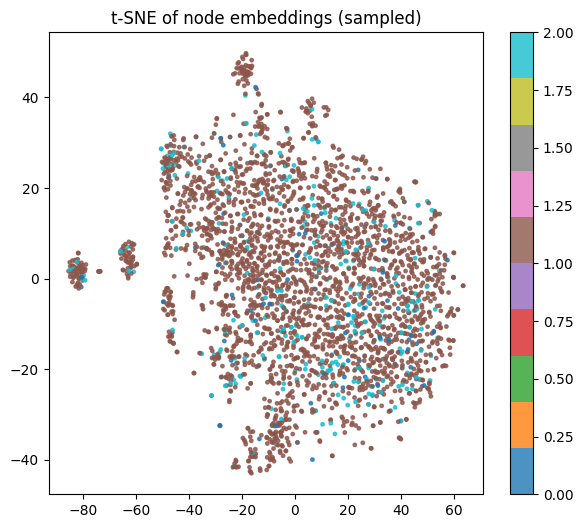

Train neighbor purity (k=10): mean=0.785 median=0.900
Class-wise average purity:
 class 0: mean purity 0.046 (n=52)
 class 1: mean purity 0.884 (n=1831)
 class 2: mean purity 0.104 (n=211)


In [ ]:
# t-SNE for visualization + neighbor purity
import numpy as np
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from collections import Counter
import matplotlib.pyplot as plt

emb = final_embedding
labels_all = data.y.cpu().numpy()
train_idx = np.where(data.train_mask.cpu().numpy())[0]
val_idx = np.where(data.val_mask.cpu().numpy())[0]
test_idx = np.where(data.test_mask.cpu().numpy())[0]

sample_idx = np.random.choice(len(emb), size=min(3000, len(emb)), replace=False)
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
z = tsne.fit_transform(emb[sample_idx])

plt.figure(figsize=(7,6))
plt.scatter(z[:,0], z[:,1], c=labels_all[sample_idx], cmap='tab10', s=6, alpha=0.8)
plt.title("t-SNE of node embeddings (sampled)")
plt.colorbar()
plt.show()

k = 10
nn = NearestNeighbors(n_neighbors=k+1).fit(emb)
nbrs = nn.kneighbors(emb[train_idx], return_distance=False)[:,1:]
purities = []
for i, idxs in enumerate(nbrs):
    true_label = labels_all[train_idx[i]]
    nbr_labels = labels_all[idxs]
    purities.append((nbr_labels == true_label).mean())
print("Train neighbor purity (k=%d): mean=%.3f median=%.3f" % (k, np.mean(purities), np.median(purities)))
print("Class-wise average purity:")
for c in np.unique(labels_all):
    ids = train_idx[labels_all[train_idx]==c]
    if len(ids)>0:
        p = []
        for i, node in enumerate(ids):
            nbrs = nn.kneighbors([emb[node]], return_distance=False)[:,1:][0]
            p.append((labels_all[nbrs] == c).mean())
        print(f" class {c}: mean purity {np.mean(p):.3f} (n={len(ids)})")

In [ ]:
import torch
import numpy as np
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score


data = Data(
    x=torch.tensor(final_embedding, dtype=torch.float),
    edge_index=torch.tensor(edges, dtype=torch.long),
    y=torch.tensor(labels, dtype=torch.long),
    edge_attr=torch.tensor(edge_attr, dtype=torch.float)
)

num_nodes = data.num_nodes
indices = np.arange(num_nodes)

train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.40, random_state=42)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask


class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, edge_feat_dim=4):
        super(GCN, self).__init__()
        self.edge_mlp = torch.nn.Linear(edge_feat_dim, 1)
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        ew = torch.sigmoid(self.edge_mlp(edge_attr)).squeeze()
        x = self.conv1(x, edge_index, edge_weight=ew)
        x = torch.relu(x)
        x = self.conv2(x, edge_index, edge_weight=ew)
        return x


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(input_dim=final_embedding.shape[1], hidden_dim=128, output_dim=3).to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = torch.nn.CrossEntropyLoss()

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
    print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

model.eval()
with torch.no_grad():
    out = model(data)
    _, pred = out.max(dim=1)

y_true = data.y[data.test_mask].cpu().numpy()
y_pred = pred[data.test_mask].cpu().numpy()

test_acc = accuracy_score(y_true, y_pred)


prec_micro, rec_micro, f1_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Micro  - Precision: {prec_micro:.4f}, Recall: {rec_micro:.4f}, F1: {f1_micro:.4f}")
print(f"Macro  - Precision: {prec_macro:.4f}, Recall: {rec_macro:.4f}, F1: {f1_macro:.4f}")
print(f"Weighted - Precision: {prec_weighted:.4f}, Recall: {rec_weighted:.4f}, F1: {f1_weighted:.4f}")



Epoch 1, Train Loss: 1.1045, Val Loss: 1.0946
Epoch 2, Train Loss: 1.0774, Val Loss: 1.0705
Epoch 3, Train Loss: 1.0510, Val Loss: 1.0469
Epoch 4, Train Loss: 1.0253, Val Loss: 1.0238
Epoch 5, Train Loss: 1.0003, Val Loss: 1.0014
Epoch 6, Train Loss: 0.9759, Val Loss: 0.9795
Epoch 7, Train Loss: 0.9523, Val Loss: 0.9582
Epoch 8, Train Loss: 0.9294, Val Loss: 0.9375
Epoch 9, Train Loss: 0.9071, Val Loss: 0.9175
Epoch 10, Train Loss: 0.8856, Val Loss: 0.8980
Epoch 11, Train Loss: 0.8647, Val Loss: 0.8791
Epoch 12, Train Loss: 0.8446, Val Loss: 0.8608
Epoch 13, Train Loss: 0.8251, Val Loss: 0.8432
Epoch 14, Train Loss: 0.8063, Val Loss: 0.8261
Epoch 15, Train Loss: 0.7881, Val Loss: 0.8096
Epoch 16, Train Loss: 0.7707, Val Loss: 0.7937
Epoch 17, Train Loss: 0.7539, Val Loss: 0.7784
Epoch 18, Train Loss: 0.7377, Val Loss: 0.7637
Epoch 19, Train Loss: 0.7222, Val Loss: 0.7495
Epoch 20, Train Loss: 0.7073, Val Loss: 0.7359
Epoch 21, Train Loss: 0.6930, Val Loss: 0.7228
Epoch 22, Train Loss: 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
